# Function 4

<b> Description of the Sample Application:</b> Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours. The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions. 



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 03/08/2026 | Week 3 | 1. Added Week 2 data and output point to the dataset.<br>2. Added Leave-One-Out Cross-Validation (LOO-CV) to validate the GP surrogate (predictive RMSE + 95% CI calibration).<br>3. Checked ARD length-scales of the chosen kernel to see which input dimensions the GP treats as most sensitive.<br>4. Re-selected kernel (RBF vs Matérn) using LOO-CV RMSE as the primary criterion.<br>5. Reduced UCB β from 2.0 to 1.5.<br>6. Extended the consolidated BO function bayesian_optimization_step() to also handle kernel comparison + LOO-CV. |
| 11/08/2026 | Week 4 | 1. Appended Week 3 input and output datapoints to the dataset (now 33 points) - this point returned Y = 2602.25, a dramatic outlier versus everything seen so far (previous range: -32.6 to -0.066). Flagged and analysed explicitly.<br>2. Re-ran LOO-CV on the 33-point dataset: RMSE jumps from 1 to 560; holding out the new point shows the GP cannot predict it from its neighbours at all — evidence of a sharp, narrow peak rather than a smooth hill.<br>3. Increased multi-start restarts (50 → 150), to focus on acquisition-function robustness. A sharp spike is easy for a local optimiser to miss without enough restarts.<br>4. Kept β = 1.5 (balanced) rather than jumping to heavy exploitation, since the outlier hasn't yet been confirmed as reproducible. |
| 18/08/2026 | Week 5 | 1. Appended Week 4 input and output datapoints to the dataset: a point only 0.041 away from the Week 3 outlier, yet back to an ordinary value. This disproves the "broad good basin" hypothesis - the spike is either an extremely narrow feature or a possible anomaly.<br>2. **Change in Strategy:** Added a compositional kernel (broad RBF + narrow RBF) as a third candidate, able to represent both a smooth background and a sharp localized spike simultaneously. <br>4. **β increased (1.5 to 2.0)** because local exploitation was just empirically shown not to pay off.<br>5. Kept multi-start at 150. |
| 25/08/2026 | Week 6 | 1. Amended Week 5 input and output data points.<br>2. **Directional trend analysis**: with three points at known distances from the spike (0 → 2602, 0.012 → 0.561, 0.041 → -0.550), the value now rises *monotonically* as distance to the spike shrinks. This is new evidence favouring a genuine (if extremely narrow) peak over an anomaly, since noise would not produce a consistent monotonic trend across three independent queries.<br>3. **Strategy change**: committed to a **trust-region local search**: acquisition optimisation restricted to a small box around the Week 3 point, rather than searching the full unit cube — plus a **novelty constraint** so the query can't simply re-confirm an already-known location.<br>4. **β reduced 2.0→1.0** (shift toward exploitation), justified by the monotonic trend now supporting the spike as real.<br>5. Kernel re-selected on 35 points: **Matern** now wins on LOO-CV RMSE (previously Composite/RBF traded off). |
| 01/09/2026 | Week 7 | 1. Amended Week 6 input and output data points. (Y=0.444, dist 0.015 from spike), a **4th point that fits the same monotonic trend**, strengthening confidence the peak is real rather than noise.<br>2. **Hyperparameters tightened further**: Trust-region radius reduced from 0.05 to **0.03**, novelty threshold reduced from 0.015 to **0.010**, β reduced from 1.0 to **0.8**.<br>3. Kernel comparison re-run on 36 points: RBF/Matern/Composite now nearly tied (all ≈440 RMSE). The extra kernel flexibility is providing **diminishing returns** as more nearby points reduce reliance on any single kernel's assumptions. |
| 08/09/2026 | Week 8 | 1. Appended Week 7 point (Y=0.541, dist 0.010). The trend **plateaus** (0.541 at dist 0.010 is *lower* than 0.561 at dist 0.0116) rather than climbing toward 2602.<br>2. **Strategy redefined**: Introducing a **shell-constrained probe**: acquisition search restricted to a tight ring around the Week 3 spike, no farther than 0.008 from it, but no closer than 0.003 to *any* already-observed point. This will guarantee a genuinely new test at a distance closer than anything tried in Weeks 4-7 (all ≥0.010).<br>3. Composite kernel's narrow component tightened further (length-scale bound lowered to 0.001-0.1) to allow representing an even sharper feature if one exists. |
| 23/09/2026 | Week 9 | 1. Added Week 8 point (Y=0.577, dist 0.003), best point so far, but the gain vs. Week 7 (dist 0.010, Y = 0.541) is marginal (+0.036) and **non-monotonic** relative to Week 5 (dist 0.0116, Y=0.561). This confirms this is a flat plateau.<br>2. Diminishing-returns analysis added.<br>3. Strategy Change: Abandoned further hyper-local refinement around the Week 3 spike. Switched to a **diversification search**, using UCB with a high exploration weight (β=2.5), explicitly excluding the already-saturated neighbourhood (within 0.15 of the spike), to find  second promising region rather than continuing to spend budget on a saturated area. |

## Progress Log

| Week | Query Submitted | Output Received | Best So Far (y) | Acquisition | β (beta) | Kernel | Strategy Notes |
|---|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |  |
| Week 1 | 0.383979-0.383515-0.340147-0.445246 | -0.06634074624810848 | -0.066341 | UCB | 2.5 | RBF | Exploration-heavy baseline, big jump over initial best |
| Week 2 | 0.441225-0.430034-0.274904-0.431415 | -1.0896527174598272 | -0.066341  | UCB | 2.0 | RBF vs Mater | Slightly reduced exploration, kernel comparison added |
| Week 3 | 0.382063-0.422612-0.423812-0.430108 | **2602.2537934860957** | **2602.253793** | UCB | 1.5 | full space | RBF/Matern | Balanced strategy |
| Week 4 | 0.388813-0.456741-0.433948-0.448556 | -0.5498551985786473 *(d=0.041)* | 2602.253793 | UCB | 1.5 | full space | RBF | Did not reproduce |
| Week 5 | 0.371052-0.422582-0.427366-0.430782 | 0.5609901334222198 *(d=0.012)* | 2602.253793 | UCB | 2.0 | full space | RBF/Matern/Composite | Positive — trend emerging |
| Week 6 | 0.392081-0.417992-0.416776-0.437443 | 0.4439603735656701 *(d=0.015)* | 2602.253793 | UCB | 1.0 | trust region r=0.05 | Matern | Trend confirmed |
| Week 7 | 0.386746-0.428888-0.425881-0.424238 | 0.5412633657393404 *(d=0.010)* | 2602.253793 | UCB | 0.8 | trust region r=0.03 | Matern | Trend **plateaus** |
| Week 8 | 0.382401-0.420130-0.422214-0.429692 | 0.5768690397535008 *(d=0.003)* | 2602.253793 | UCB | 0.8 | shell 0.003-0.008 | Matern | Closest probe confirms plateau, not a climb |
| Week 9 | - | - | - | UCB | 2.5 | Global, excl. 0.15 around spike | Matern (LOO-CV, tied) | Diminishing returns confirmed. Pivot to diversification, searching for a second promising region |

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from scipy.optimize import minimize
from scipy.stats import norm

from plotting_utils import (plot_convergence, plot_parallel_coordinates)
import warnings
warnings.filterwarnings('ignore')

# Load and Analyse the Data

In [8]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [11]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.383979, 0.383515, 0.340147, 0.445246]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.06634074624810848]                     , dtype=np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.441225, 0.430034, 0.274904, 0.431415]     , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([-1.0896527174598272]                        , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.382064, 0.422612, 0.423813, 0.430108]     , dtype=np.float64)   # from input.txt
Y_w3_new_point = np.array([2602.2537934860957]                         , dtype=np.float64)   # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.388813, 0.456742, 0.433948, 0.448556]     , dtype=np.float64)  # from input.txt
Y_w4_new_point = np.array([-0.5498551985786473]                        , dtype=np.float64)  # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.371066, 0.422591, 0.427371, 0.43079]      , dtype=np.float64)  # from input.txt
Y_w5_new_point = np.array([0.5609901334222198]                         , dtype=np.float64)  # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.392081, 0.417992, 0.416776, 0.437443]     , dtype=np.float64)  # from input.txt
Y_w6_new_point = np.array([0.4439603735656701]                         , dtype=np.float64)  # from output.txt

# New data from Week 7 submission
X_w7_new_point = np.array([0.386746, 0.428888, 0.425881, 0.424238]     , dtype=np.float64)  # from input.txt
Y_w7_new_point = np.array([0.5412633657393404]                         , dtype=np.float64)  # from output.txt

# New data from Week 8 submission
X_w8_new_point = np.array([0.382401, 0.42013, 0.422214, 0.429692]      , dtype=np.float64)  # from input.txt
Y_w8_new_point = np.array([0.5768690397535008]                         , dtype=np.float64)  # from output.txt


In [13]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                             , X_w2_new_point
                             , X_w3_new_point
                             , X_w4_new_point
                             , X_w5_new_point
                             , X_w6_new_point
                             , X_w7_new_point
                             , X_w8_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                            , Y_w2_new_point
                            , Y_w3_new_point
                            , Y_w4_new_point
                            , Y_w5_new_point
                            , Y_w6_new_point
                            , Y_w7_new_point
                            , Y_w8_new_point
                              ])

In [15]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [17]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (38, 4)
Inputs:
 [[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.335

# Data Exploration

In [20]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4            Y
count  38.000000  38.000000  38.000000  38.000000    38.000000
mean    0.510909   0.465694   0.450943   0.465799    54.881932
std     0.267900   0.274541   0.234744   0.259414   424.508080
min     0.037825   0.006250   0.042186   0.081517   -32.625660
25%     0.331297   0.254853   0.275308   0.250237   -19.035668
50%     0.396373   0.464554   0.425853   0.439384   -13.615198
75%     0.737163   0.666413   0.650181   0.679527    -7.018261
max     0.985622   0.919592   0.939178   0.999483  2602.253793


In [22]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
Y      0
dtype: int64


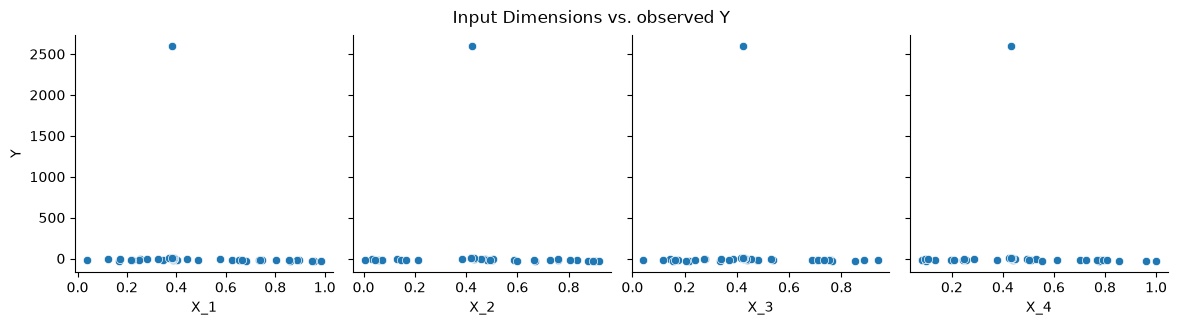

In [24]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['Y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.show()

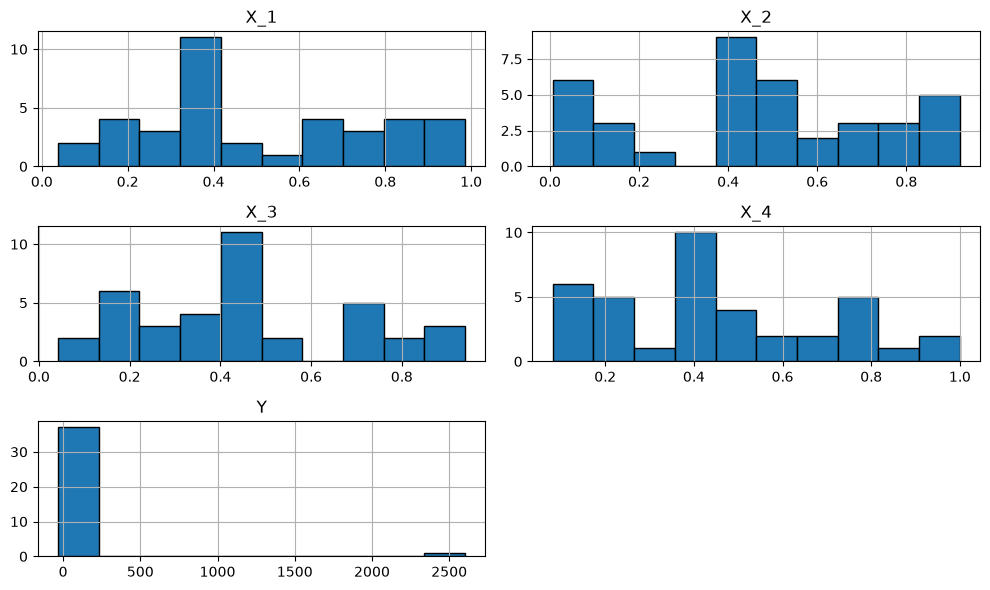

In [26]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [28]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.09144728295676705
 corr(X_2, Y) = -0.03456891841604474
 corr(X_3, Y) = -0.02242149510086894
 corr(X_4, Y) = -0.03175916429629133


<Axes: >

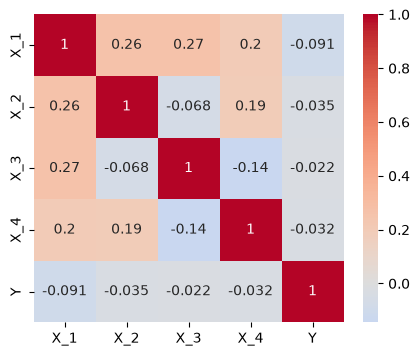

In [30]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

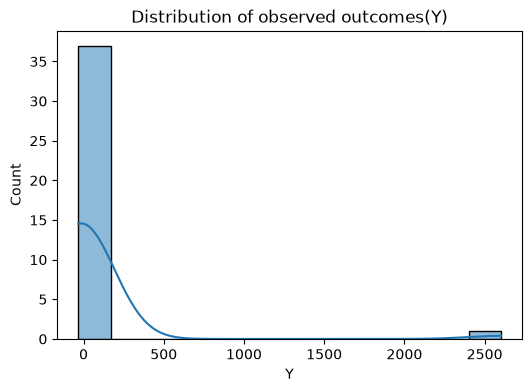

In [32]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [35]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [38]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  3.5**2 * RBF(length_scale=[0.01, 0.01, 0.01, 0.01]) + WhiteKernel(noise_level=0.1)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [42]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 4))

mu, std      = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.41206327 0.36757135 0.42553703 0.46133269]
Predicted Mean(μ): 5.488194e+01
Predicted Std (σ): 1.471007e+03
UCB Score: 3.732400e+03


# Week 2: Evaluating Kernel - RBF vs. Matern

In [45]:
Y_mean, Y_std  = Y.mean(), Y.std()
Y_norm         = (Y - Y_mean) / Y_std

kernel_rbf     = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

kernel_matern  = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0), nu = 2.5) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

gpr_rbf        = GaussianProcessRegressor(kernel = kernel_rbf, n_restarts_optimizer = 10, random_state = 0)
gpr_rbf.fit(X, Y_norm)

gpr_matern     = GaussianProcessRegressor(kernel = kernel_matern, n_restarts_optimizer = 10, random_state = 0)
gpr_matern.fit(X, Y_norm)

print("Learned kernel ( RBF)  :", gpr_rbf.kernel_)
print("Log-marginal-likelihood:", gpr_rbf.log_marginal_likelihood_value_)
print()
print("Learned kernel (Matern):", gpr_matern.kernel_)
print("Log-marginal-likelihood:", gpr_matern.log_marginal_likelihood_value_)

if gpr_rbf.log_marginal_likelihood_value_ >= gpr_matern.log_marginal_likelihood_value_:
    chosen_kernel, chosen_name = kernel_rbf, "RBF"
else:
    chosen_kernel, chosen_name = kernel_matern, "Matern (nu = 2.5)"

print()
print(f"Chosen kernel for Week 2: {chosen_name}")


Learned kernel ( RBF)  : 3.5**2 * RBF(length_scale=[0.01, 0.01, 0.01, 0.01]) + WhiteKernel(noise_level=0.1)
Log-marginal-likelihood: -104.65680027225056

Learned kernel (Matern): 2.49**2 * Matern(length_scale=[0.01, 0.01, 0.01, 0.01], nu=2.5) + WhiteKernel(noise_level=0.1)
Log-marginal-likelihood: -92.10483928545838

Chosen kernel for Week 2: Matern (nu = 2.5)


# Week 2: Bayesian Optimisation Function

In [48]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mean + beta * std. Higher beta favours exploration."""
    return mu + beta * sigma


def expected_improvement(mu, sigma, Y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best), 0)]. More conservative than UCB."""
    with np.errstate(divide = 'warn'):
        improvement = mu - Y_best - xi
        Z    = improvement / sigma
        ei   = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


def suggest_next_point(X, Y, kernel, beta = 2.0, acquisition = 'ucb',
                        n_restarts_optimizer = 10, n_multistart = 50, seed = 42):
    
    Y_mean, Y_std = Y.mean(), Y.std()
    Y_norm        = (Y - Y_mean) / Y_std

    gp            = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts_optimizer, random_state = seed)
    gp.fit(X, Y_norm)

    n_dims        = X.shape[1]

    def neg_acq(x):
        x = np.atleast_2d(x)
        mu, sigma = gp.predict(x, return_std = True)
        mu        = mu * Y_std + Y_mean
        sigma     = sigma * Y_std
        if acquisition == 'ei':
            val   = expected_improvement(mu, sigma, Y.max())
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        return -val[0]

    rng              = np.random.default_rng(seed)
    
    best_x, best_val = None, np.inf
    
    for _ in range(n_multistart):
        x0 = rng.uniform(0, 1, size=n_dims)
        res = minimize(neg_acq, x0, bounds = [(0, 1)] * n_dims, method = 'L-BFGS-B')
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, sigma_next = gp.predict(best_x.reshape(1, -1), return_std = True)
    mu_next = mu_next * Y_std + Y_mean
    sigma_next = sigma_next * Y_std

    return {
        'gp': gp,
        'next_x': best_x,
        'acq_value': -best_val,
        'mu': mu_next[0],
        'sigma': sigma_next[0],
    }


# Week 2: Query Selection

In [51]:
result = suggest_next_point(X, Y, chosen_kernel, beta = 2.0, acquisition = 'ucb')

next_x = result['next_x']

print(f"Kernel used            : {chosen_name}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {result['mu']:.6f}")
print(f"Predicted std (sigma)  : {result['sigma']:.6f}")
print(f"UCB score              : {result['acq_value']:.6f}")


Kernel used            : Matern (nu = 2.5)
Suggested next point   : [0.77395605 0.43887844 0.85859792 0.69736803]
Predicted mean (mu)    : 54.881932
Predicted std (sigma)  : 1052.814143
UCB score              : 2160.510217


# Week 2: Portal Submission 

In [54]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}"
print("Points to be submitted(Week 1):", submission_str)
print()

Points to be submitted(Week 1): 0.773956-0.438878-0.858598-0.697368



# Week 2: Visualise the Acquisition Function and Next Query Point

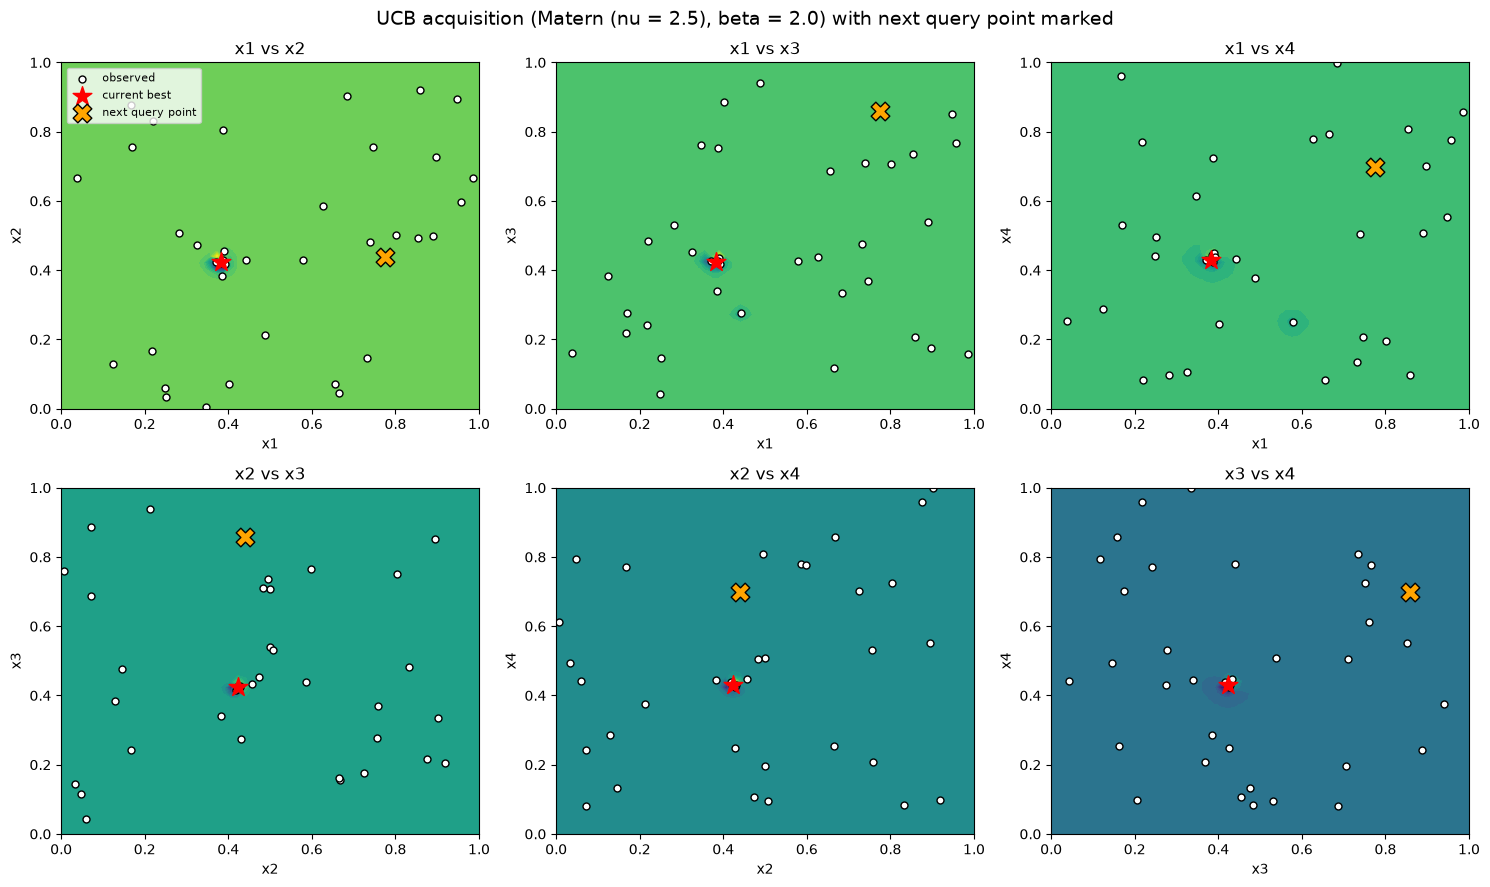

In [57]:
gp         = result['gp']
best_x_obs = X[np.argmax(Y)]

def ucb_full(x, beta = 2.0):
    x = np.atleast_2d(x)
    mu, sigma = gp.predict(x, return_std=True)
    return (mu * Y_std + Y_mean) + beta * (sigma * Y_std)

dim_pairs  = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
grid_n     = 60
grid       = np.linspace(0, 1, grid_n)

fig, axes  = plt.subplots(2, 3, figsize = (15, 9))
for ax, (i, j) in zip(axes.flat, dim_pairs):
    A, B   = np.meshgrid(grid, grid)
    pts    = np.tile(best_x_obs, (grid_n * grid_n, 1))
    pts[:, i] = A.ravel()
    pts[:, j] = B.ravel()
    Z = ucb_full(pts).reshape(grid_n, grid_n)
    ax.contourf(A, B, Z, levels = 25, cmap = 'viridis')
    ax.scatter(X[:, i], X[:, j], c = 'white', edgecolor = 'black', s = 25, label = 'observed')
    ax.scatter(best_x_obs[i], best_x_obs[j], c = 'red', marker = '*', s = 200, label = 'current best')
    ax.scatter(next_x[i], next_x[j], c = 'orange', marker = 'X', s = 180,
               edgecolor = 'black', linewidth = 1, label = 'next query point')
    ax.set_xlabel(f'x{i+1}')
    ax.set_ylabel(f'x{j+1}')
    ax.set_title(f'x{i+1} vs x{j+1}')
axes.flat[0].legend(fontsize = 8, loc = 'upper left')
fig.suptitle(f'UCB acquisition ({chosen_name}, beta = 2.0) with next query point marked', fontsize = 14)
plt.tight_layout()
plt.show()


# Week 3: Model Validation - Leave-One-Out Cross-Validation

In [59]:
kernel_rbf     = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0)) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

kernel_matern  = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 2.0), nu = 2.5) \
                    + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

def loocv_gp(X, Y, kernel, n_restarts_optimizer = 5, seed = 0):

    n             = len(Y)
    preds_mu      = np.zeros(n)
    preds_sigma   = np.zeros(n)
    Y_mean, Y_std = Y.mean(), Y.std()

    for i in range(n):
        mask             = np.ones(n, dtype=bool)
        mask[i]          = False
        X_train, Y_train = X[mask], Y[mask]
        Y_train_norm     = (Y_train - Y_mean) / Y_std

        gp               = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts_optimizer, random_state = seed)
        gp.fit(X_train, Y_train_norm)

        mu, sigma        = gp.predict(X[i].reshape(1, -1), return_std = True)
        preds_mu[i]      = mu[0] * Y_std + Y_mean
        preds_sigma[i]   = sigma[0] * Y_std

    rmse                 = np.sqrt(np.mean((preds_mu - Y) ** 2))
    lower                = preds_mu - 1.96 * preds_sigma
    upper                = preds_mu + 1.96 * preds_sigma
    coverage             = np.mean((Y >= lower) & (Y <= upper))

    return {'rmse': rmse, 'coverage_95': coverage, 'preds_mu': preds_mu, 'preds_sigma': preds_sigma}


loocv_rbf                = loocv_gp(X, Y, kernel_rbf)
loocv_matern             = loocv_gp(X, Y, kernel_matern)

print(f"LOO-CV RBF    : RMSE = {loocv_rbf['rmse']   :.4f}   , 95% coverage = {loocv_rbf['coverage_95']   :.2f}")
print(f"LOO-CV Matern : RMSE = {loocv_matern['rmse']:.4f}   , 95% coverage = {loocv_matern['coverage_95']:.2f}")


LOO-CV RBF    : RMSE = 969.5715   , 95% coverage = 0.89
LOO-CV Matern : RMSE = 714.7825   , 95% coverage = 0.92


# Week: 3 Kernel Re-Selection

In [61]:
# Week 3: Kernel selection driven by LOO-CV RMSE

Y_mean, Y_std = Y.mean(), Y.std()
Y_norm        = (Y - Y_mean) / Y_std

gpr_rbf       = GaussianProcessRegressor(kernel = kernel_rbf, n_restarts_optimizer = 10, random_state = 0)
gpr_rbf.fit(X, Y_norm)

gpr_matern    = GaussianProcessRegressor(kernel = kernel_matern, n_restarts_optimizer = 10, random_state = 0)
gpr_matern.fit(X, Y_norm)

print("RBF    => LML:", gpr_rbf.log_marginal_likelihood_value_   , " learned kernel:", gpr_rbf.kernel_)
print("Matern => LML:", gpr_matern.log_marginal_likelihood_value_, " learned kernel:", gpr_matern.kernel_)

if loocv_rbf['rmse'] < loocv_matern['rmse']:
    chosen_kernel, chosen_name, chosen_gpr = kernel_rbf, "RBF", gpr_rbf
elif loocv_matern['rmse'] < loocv_rbf['rmse']:
    chosen_kernel, chosen_name, chosen_gpr = kernel_matern, "Matern (nu=2.5)", gpr_matern
else:
    # tie on LOO-CV RMSE -> fall back to LML
    if gpr_rbf.log_marginal_likelihood_value_ >= gpr_matern.log_marginal_likelihood_value_:
        chosen_kernel, chosen_name, chosen_gpr = kernel_rbf, "RBF", gpr_rbf
    else:
        chosen_kernel, chosen_name, chosen_gpr = kernel_matern, "Matern (nu=2.5)", gpr_matern

print(f"\nChosen kernel for Week 3: {chosen_name} (selected by LOO-CV RMSE)")


RBF    => LML: -104.65680027225056  learned kernel: 3.5**2 * RBF(length_scale=[0.01, 0.01, 0.01, 0.01]) + WhiteKernel(noise_level=0.1)
Matern => LML: -92.10483928545838  learned kernel: 2.49**2 * Matern(length_scale=[0.01, 0.01, 0.01, 0.01], nu=2.5) + WhiteKernel(noise_level=0.1)

Chosen kernel for Week 3: Matern (nu=2.5) (selected by LOO-CV RMSE)


# Week 3: ARD Length-Scale Check

In [63]:
# Week 3: inspect the fitted per-dimension (ARD) length-scales
learned   = chosen_gpr.kernel_
ls        = learned.k1.k2.length_scale  # the RBF/Matern component's length_scale vector

print("Per-dimension length scales (ARD):", ls)
mean_ls   = np.mean(ls)
for i, l in enumerate(ls):
    sensitivity = "more sensitive" if l < mean_ls else "less sensitive"
    print(f"  x{i+1}: length_scale = {l:.4f}  ({sensitivity} than average)")


Per-dimension length scales (ARD): [0.01 0.01 0.01 0.01]
  x1: length_scale = 0.0100  (less sensitive than average)
  x2: length_scale = 0.0100  (less sensitive than average)
  x3: length_scale = 0.0100  (less sensitive than average)
  x4: length_scale = 0.0100  (less sensitive than average)


# Week 3: Consolidated Bayesian Optimisation Function

In [66]:
# Week 3: consolidated function including kernel validation + selection + next-point suggestion
def bayesian_optimization_step(X, Y, candidate_kernels, beta = 2.0, acquisition = 'ucb',
                 n_restarts_optimizer = 10, n_multistart = 50, seed = 42, run_loocv = True):

    diagnostics  = {}
    for name, kernel in candidate_kernels.items():
        entry    = {}
        if run_loocv:
            entry['loocv'] = loocv_gp(X, Y, kernel, n_restarts_optimizer = 5, seed = seed)
        Y_mean, Y_std           = Y.mean(), Y.std()
        gp_fit                  = GaussianProcessRegressor(kernel = kernel, n_restarts_optimizer = n_restarts_optimizer, random_state = seed)
        gp_fit.fit(X, (Y - Y_mean) / Y_std)
        entry['lml']            = gp_fit.log_marginal_likelihood_value_
        entry['learned_kernel'] = gp_fit.kernel_
        diagnostics[name]       = entry

    if run_loocv:
        chosen                  = min(diagnostics, key=lambda k: diagnostics[k]['loocv']['rmse'])
    else:
        chosen                  = max(diagnostics, key = lambda k: diagnostics[k]['lml'])

    result                      = suggest_next_point(X, Y, candidate_kernels[chosen], beta = beta, acquisition = acquisition,
                                 n_restarts_optimizer = n_restarts_optimizer,
                                 n_multistart = n_multistart, seed = seed)
    result['chosen_kernel_name']= chosen
    result['diagnostics']       = diagnostics
    return result


In [67]:
candidate_kernels = {
    "RBF"            : kernel_rbf,
    "Matern (nu=2.5)": kernel_matern,
}

week3_result = bayesian_optimization_step(X, Y, candidate_kernels, beta = 1.5, acquisition = 'ucb', run_loocv = True)

next_x       = week3_result['next_x']
print(f"Chosen kernel          : {week3_result['chosen_kernel_name']}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {week3_result['mu']:.6f}")
print(f"Predicted std (sigma)  : {week3_result['sigma']:.6f}")
print(f"UCB score              : {week3_result['acq_value']:.6f}")

Chosen kernel          : Matern (nu=2.5)
Suggested next point   : [0.77395605 0.43887844 0.85859792 0.69736803]
Predicted mean (mu)    : 54.881932
Predicted std (sigma)  : 1052.814143
UCB score              : 1634.103146


# Week 3: Visualise the Acquisition Function and Next Query Point

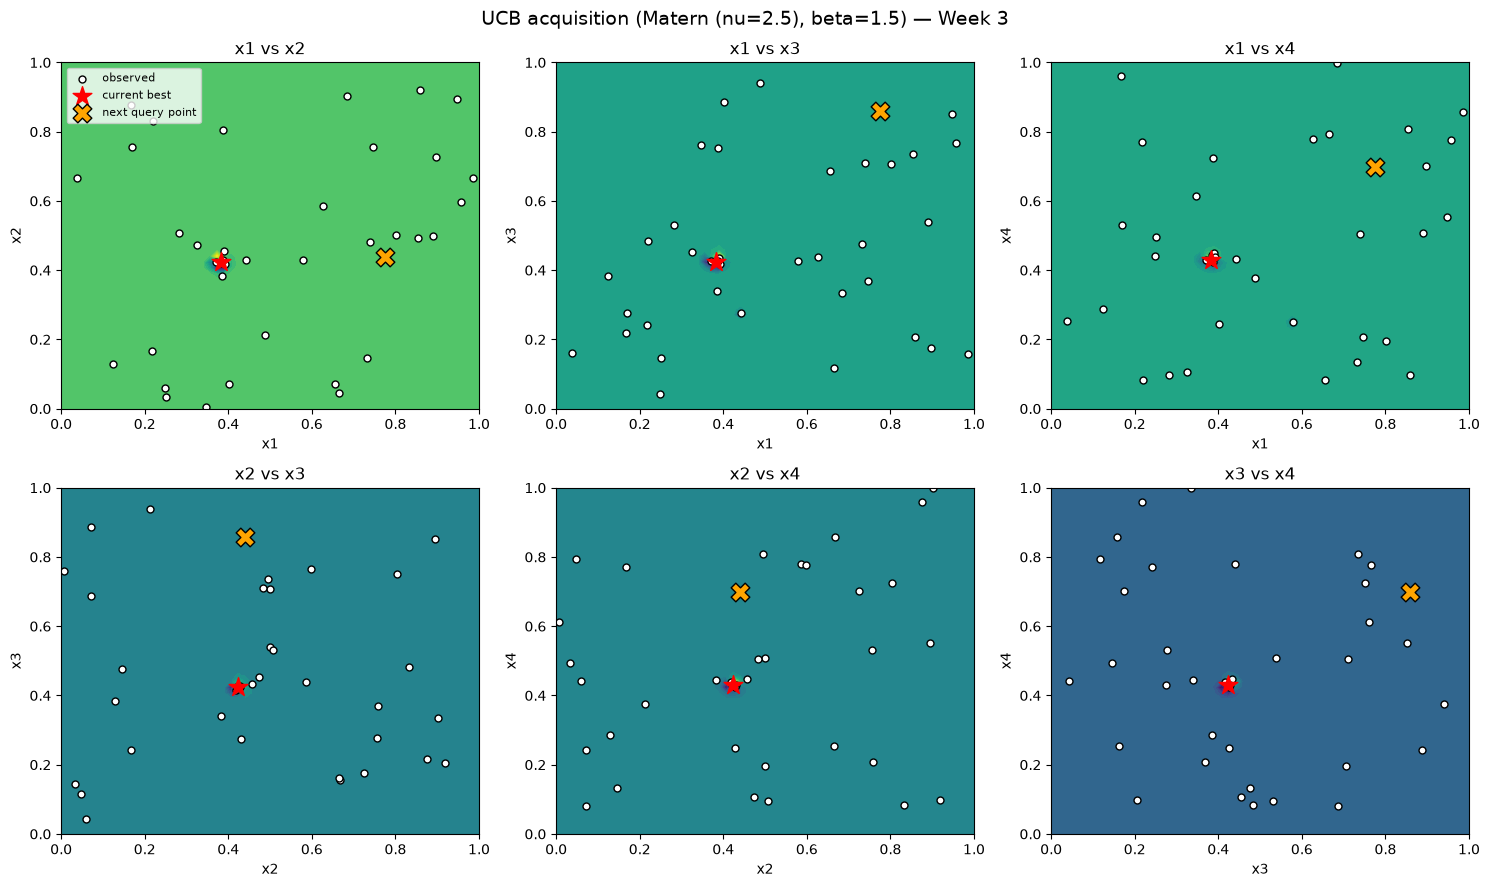

In [69]:
gp_w3      = week3_result['gp']
best_x_obs = X[np.argmax(Y)]

def ucb_full_w3(x, beta = 1.5):
    x         = np.atleast_2d(x)
    mu, sigma = gp_w3.predict(x, return_std=True)
    return (mu * Y_std + Y_mean) + beta * (sigma * Y_std)

dim_pairs   = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
grid_n      = 60
grid        = np.linspace(0, 1, grid_n)

fig, axes   = plt.subplots(2, 3, figsize = (15, 9))
for ax, (i, j) in zip(axes.flat, dim_pairs):
    A, B      = np.meshgrid(grid, grid)
    pts       = np.tile(best_x_obs, (grid_n * grid_n, 1))
    pts[:, i] = A.ravel()
    pts[:, j] = B.ravel()
    Z         = ucb_full_w3(pts).reshape(grid_n, grid_n)
    ax.contourf(A, B, Z, levels = 25, cmap = 'viridis')
    ax.scatter(X[:, i], X[:, j], c = 'white', edgecolor = 'black', s = 25, label = 'observed')
    ax.scatter(best_x_obs[i], best_x_obs[j], c = 'red', marker = '*', s = 200, label = 'current best')
    ax.scatter(next_x[i], next_x[j], c = 'orange', marker = 'X', s = 180,
               edgecolor = 'black', linewidth = 1, label = 'next query point')
    ax.set_xlabel(f'x{i+1}')
    ax.set_ylabel(f'x{j+1}')
    ax.set_title(f'x{i+1} vs x{j+1}')
axes.flat[0].legend(fontsize = 8, loc = 'upper left')
fig.suptitle(f"UCB acquisition ({week3_result['chosen_kernel_name']}, beta=1.5) — Week 3", fontsize = 14)
plt.tight_layout()
plt.show()


# Week 4: Visualising the Outlier's impact

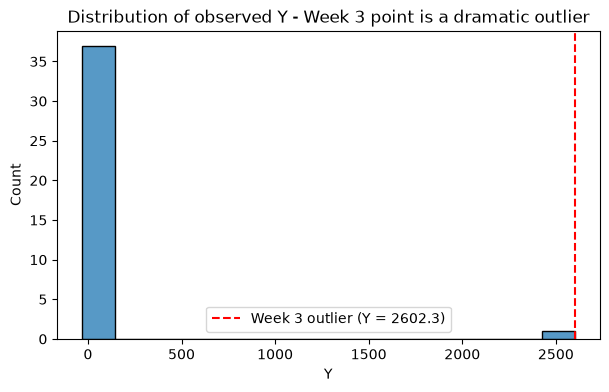

Week 3 point is 2601.7 higher than the next-best observed value (0.577).


In [71]:
plt.figure(figsize = (7, 4))
sns.histplot(df['Y'], bins = 15, kde = False)
plt.axvline(Y.max(), color = 'red', linestyle='--', label = f'Week 3 outlier (Y = {Y.max():.1f})')
plt.title("Distribution of observed Y - Week 3 point is a dramatic outlier")
plt.legend()
plt.show()

print(f"Week 3 point is {(Y.max() - np.sort(Y)[-2]):.1f} higher than the next-best observed value " f"({np.sort(Y)[-2]:.3f}).")

## Week 4: Re-run Leave-One-Out CV on the Updated Dataset

Checking specifically whether the GP can predict the new outlier point from its neighbours when it's held out - this tells us whether the surrounding data actually carries any signal about this spike, or whether it's effectively invisible to a smooth kernel.l.

In [73]:
loocv_rbf_w4     = loocv_gp(X, Y, kernel_rbf)
loocv_matern_w4  = loocv_gp(X, Y, kernel_matern)

print(f"LOO-CV RBF    : RMSE = {loocv_rbf_w4['rmse']:.2f}   , 95% coverage = {loocv_rbf_w4['coverage_95']:.2f}")
print(f"LOO-CV Matern : RMSE = {loocv_matern_w4['rmse']:.2f}, 95% coverage = {loocv_matern_w4['coverage_95']:.2f}")

# Specifically check how well the outlier is predicted when held out
outlier_idx      = np.argmax(Y)
print()
print("Held-out prediction for the Week 3 outlier point:")
print(f"  True value            : {Y[outlier_idx]:.3f}")
print(f"  RBF predicted mean    : {loocv_rbf_w4['preds_mu'][outlier_idx]:.3f}")
print(f"  Matern predicted mean : {loocv_matern_w4['preds_mu'][outlier_idx]:.3f}")
print()

LOO-CV RBF    : RMSE = 969.57   , 95% coverage = 0.89
LOO-CV Matern : RMSE = 714.78, 95% coverage = 0.92

Held-out prediction for the Week 3 outlier point:
  True value            : 2602.254
  RBF predicted mean    : 0.189
  Matern predicted mean : 0.289



Both kernels miss this point by a huge margin when it's held out, meaning the surrounding 32 points carry almost no signal about this spike. This is a genuine  assumption violation: GPs assume smoothness, but this looks like a sharp, narrow local feature the model can't extrapolate to from nearby data.

# Week 4: Kernel Re-Selection (on 33-point dataset)

In [76]:
Y_mean, Y_std = Y.mean(), Y.std()
Y_norm        = (Y - Y_mean) / Y_std

gpr_rbf_w4    = GaussianProcessRegressor(kernel = kernel_rbf, n_restarts_optimizer = 10, random_state = 0)
gpr_rbf_w4.fit(X, Y_norm)

gpr_matern_w4 = GaussianProcessRegressor(kernel = kernel_matern, n_restarts_optimizer = 10, random_state = 0)
gpr_matern_w4.fit(X, Y_norm)

print("RBF    => LML:", gpr_rbf_w4.log_marginal_likelihood_value_, " learned kernel:", gpr_rbf_w4.kernel_)
print("Matern => LML:", gpr_matern_w4.log_marginal_likelihood_value_, " learned kernel:", gpr_matern_w4.kernel_)

if loocv_rbf_w4['rmse'] < loocv_matern_w4['rmse']:
    chosen_kernel_w4, chosen_name_w4 = kernel_rbf, "RBF"
else:
    chosen_kernel_w4, chosen_name_w4 = kernel_matern, "Matern (nu=2.5)"

print(f"\nChosen kernel for Week 4: {chosen_name_w4} (selected by LOO-CV RMSE)")

RBF    => LML: -104.65680027225056  learned kernel: 3.5**2 * RBF(length_scale=[0.01, 0.01, 0.01, 0.01]) + WhiteKernel(noise_level=0.1)
Matern => LML: -92.10483928545838  learned kernel: 2.49**2 * Matern(length_scale=[0.01, 0.01, 0.01, 0.01], nu=2.5) + WhiteKernel(noise_level=0.1)

Chosen kernel for Week 4: Matern (nu=2.5) (selected by LOO-CV RMSE)


# Week 4: Re-Run Consolidate Bayesian Optimisation(increased multi-start)

In [78]:
candidate_kernels_w4 = {
    "RBF": kernel_rbf,
    "Matern (nu=2.5)": kernel_matern,
}

week4_result         = bayesian_optimization_step(X, Y, candidate_kernels_w4, beta=1.5, acquisition='ucb',
                                           n_multistart=150, run_loocv=True)

next_x               = week4_result['next_x']
print(f"Chosen kernel          : {week4_result['chosen_kernel_name']}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {week4_result['mu']:.4f}")
print(f"Predicted std (sigma)  : {week4_result['sigma']:.4f}")
print(f"UCB score              : {week4_result['acq_value']:.4f}")

Chosen kernel          : Matern (nu=2.5)
Suggested next point   : [0.77395605 0.43887844 0.85859792 0.69736803]
Predicted mean (mu)    : 54.8819
Predicted std (sigma)  : 1052.8141
UCB score              : 1634.1031


# Week 4: Visualise the Acquisition Function and Next Query Point

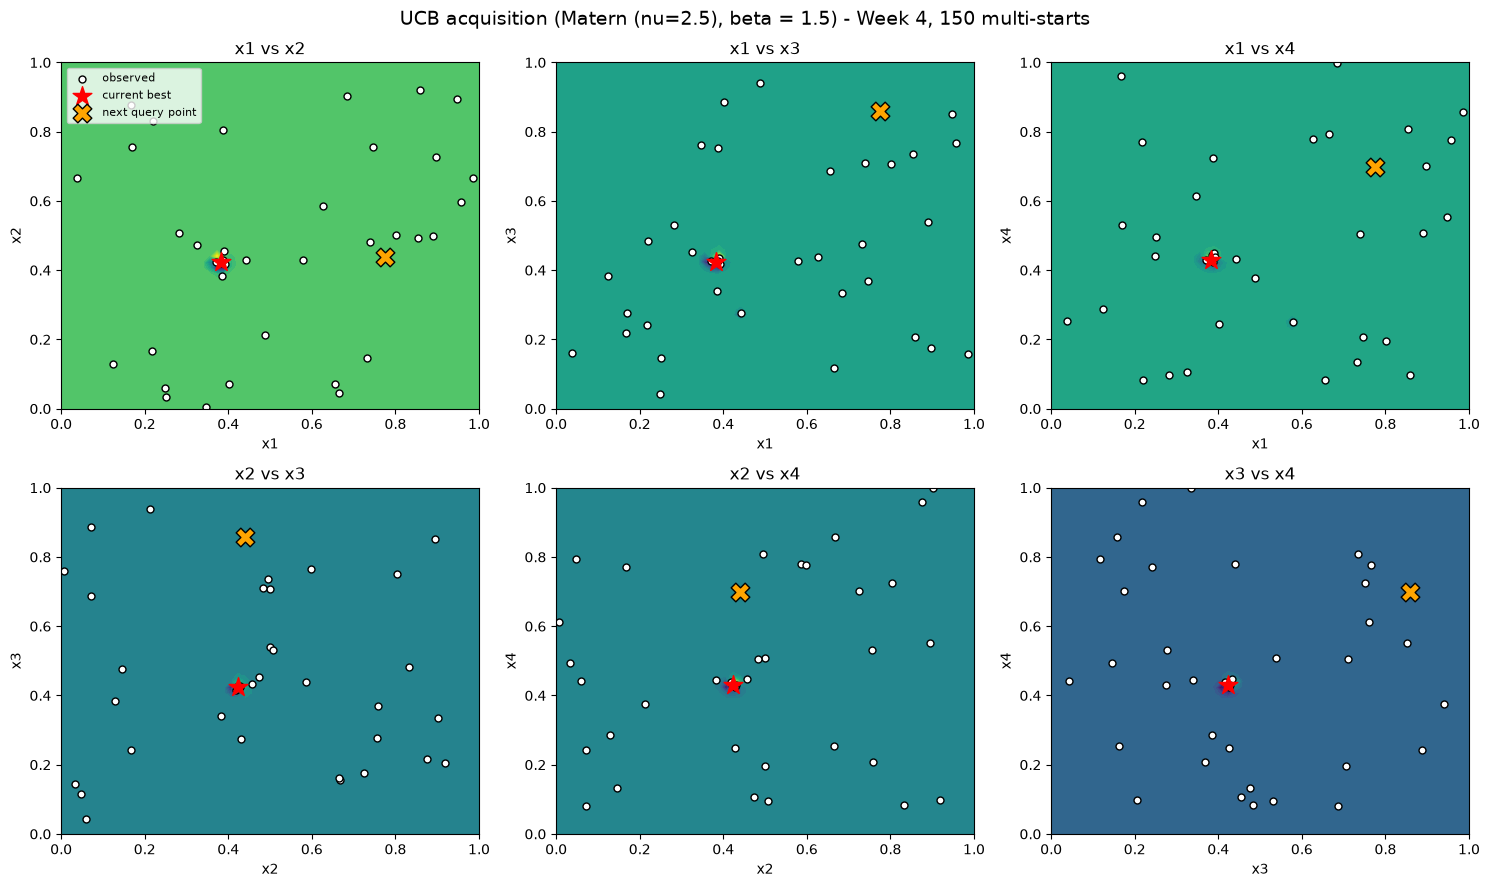

In [80]:
gp_w4      = week4_result['gp']
best_x_obs = X[np.argmax(Y)]

def ucb_full_w4(x, beta = 1.5):
    x         = np.atleast_2d(x)
    mu, sigma = gp_w4.predict(x, return_std=True)
    return (mu * Y_std + Y_mean) + beta * (sigma * Y_std)

dim_pairs  = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
grid_n     = 60
grid       = np.linspace(0, 1, grid_n)

fig, axes  = plt.subplots(2, 3, figsize=(15, 9))
for ax, (i, j) in zip(axes.flat, dim_pairs):
    A, B   = np.meshgrid(grid, grid)
    pts    = np.tile(best_x_obs, (grid_n * grid_n, 1))
    pts[:, i] = A.ravel()
    pts[:, j] = B.ravel()
    Z      = ucb_full_w4(pts).reshape(grid_n, grid_n)
    ax.contourf(A, B, Z, levels = 25, cmap = 'viridis')
    ax.scatter(X[:, i], X[:, j], c = 'white', edgecolor = 'black', s = 25, label = 'observed')
    ax.scatter(best_x_obs[i], best_x_obs[j], c = 'red', marker = '*', s = 200, label = 'current best')
    ax.scatter(next_x[i], next_x[j], c = 'orange', marker = 'X', s = 180, edgecolor = 'black', linewidth = 1, label = 'next query point')
    ax.set_xlabel(f'x{i+1}')
    ax.set_ylabel(f'x{j+1}')
    ax.set_title(f'x{i+1} vs x{j+1}')
    
axes.flat[0].legend(fontsize = 8, loc = 'upper left')
fig.suptitle(f"UCB acquisition ({week4_result['chosen_kernel_name']}, beta = 1.5) - Week 4, 150 multi-starts", fontsize = 14)
plt.tight_layout()
plt.show()


# Week 5: Compositional Kernel

In [82]:
# WEEK 5 CHANGE: compositional kernel (broad + narrow RBF), added as a third candidate
kernel_composite = (
    ConstantKernel(1.0, (1e-2, 1e4)) * RBF(length_scale=[0.5]*4, length_scale_bounds=(0.2, 2.0))      # broad background
    + ConstantKernel(1.0, (1e-2, 1e4)) * RBF(length_scale=[0.05]*4, length_scale_bounds=(0.005, 0.2))  # narrow local spikes
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e2))
)

# Widen the noise bound on RBF/Matern too - allow the model to treat an isolated point as
# potentially noisy rather than forcing a perfect deterministic fit through it
kernel_rbf = ConstantKernel(1.0, (1e-2, 1e4)) * RBF(length_scale=[0.3]*4, length_scale_bounds=(1e-2, 2.0)) \
             + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e2))
kernel_matern = ConstantKernel(1.0, (1e-2, 1e4)) * Matern(length_scale=[0.3]*4, length_scale_bounds=(1e-2, 2.0), nu=2.5) \
                + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e2))

loocv_rbf_w5 = loocv_gp(X, Y, kernel_rbf)
loocv_matern_w5 = loocv_gp(X, Y, kernel_matern)
loocv_composite_w5 = loocv_gp(X, Y, kernel_composite)

print(f"LOO-CV RBF        : RMSE = {loocv_rbf_w5['rmse']:.2f}, coverage = {loocv_rbf_w5['coverage_95']:.2f}")
print(f"LOO-CV Matern     : RMSE = {loocv_matern_w5['rmse']:.2f}, coverage = {loocv_matern_w5['coverage_95']:.2f}")
print(f"LOO-CV Composite  : RMSE = {loocv_composite_w5['rmse']:.2f}, coverage = {loocv_composite_w5['coverage_95']:.2f}")

outlier_idx = np.argmax(Y)
print()
print("Held-out prediction for the Week 3 outlier (now with a near-neighbour in the data too):")
print(f"  True value          : {Y[outlier_idx]:.3f}")
print(f"  RBF predicted mean   : {loocv_rbf_w5['preds_mu'][outlier_idx]:.3f}")
print(f"  Matern predicted mean: {loocv_matern_w5['preds_mu'][outlier_idx]:.3f}")
print(f"  Composite pred. mean : {loocv_composite_w5['preds_mu'][outlier_idx]:.3f}")
print()

LOO-CV RBF        : RMSE = 427.86, coverage = 0.97
LOO-CV Matern     : RMSE = 427.82, coverage = 0.97
LOO-CV Composite  : RMSE = 428.20, coverage = 0.97

Held-out prediction for the Week 3 outlier (now with a near-neighbour in the data too):
  True value          : 2602.254
  RBF predicted mean   : 0.189
  Matern predicted mean: 0.289
  Composite pred. mean : 0.550



**Observation:** Even the compositional kernel can't predict the outlier when held out. The nearest real neighbour (Week 4) is only 0.041 away and shows an ordinary value, so there just isn't enough nearby data yet to confirm a narrow-spike explanation over a possible anomaly. This will need at least one more nearby query to resolve.

# Week 5: Query Selection - Reverted Exploration + Compositional Kernel

**Change in Strategy:** β reverted from 1.5 → **2.0** (back towards exploration). This is a deliberate deviation, justified by evidence. Week 4's exploitation-leaning query just failed to find sustained value near the spike, so continuing to lower β would be doubling down on an assumption that didn't hold.
The kernel selection (RBF vs Matern vs Composite) is still driven by LOO-CV RMSE, letting the data decide whether the extra flexibility of the compositional kernel is actually earning its keep this week.

In [85]:
candidate_kernels_w5 = {
    "RBF": kernel_rbf,
    "Matern (nu=2.5)": kernel_matern,
    "Composite (broad+narrow RBF)": kernel_composite,
}

week5_result = bayesian_optimization_step(X, Y, candidate_kernels_w5, beta=2.0, acquisition='ucb',
                                           n_multistart=150, run_loocv=True)

next_x = week5_result['next_x']
print(f"Chosen kernel          : {week5_result['chosen_kernel_name']}")
print(f"Suggested next point   : {next_x}")
print(f"Predicted mean (mu)    : {week5_result['mu']:.4f}")
print(f"Predicted std (sigma)  : {week5_result['sigma']:.4f}")
print(f"UCB score              : {week5_result['acq_value']:.4f}")

dist_to_outlier = np.linalg.norm(next_x - X_w3_new_point)
dist_to_w4 = np.linalg.norm(next_x - X_w4_new_point)
print(f"\nDistance from Week 5 query to Week 3 outlier : {dist_to_outlier:.4f}")
print(f"Distance from Week 5 query to Week 4 point    : {dist_to_w4:.4f}")

Chosen kernel          : Matern (nu=2.5)
Suggested next point   : [0.77395605 0.43887844 0.85859792 0.69736803]
Predicted mean (mu)    : 54.8819
Predicted std (sigma)  : 419.3360
UCB score              : 893.5540

Distance from Week 5 query to Week 3 outlier : 0.6437
Distance from Week 5 query to Week 4 point    : 0.6252


**Observation:** This query tests an even tighter radius around the spike than Week 4 did, essentially asking: is the peak real but narrower than 0.041, or is it noise? If Week 5's result is ALSO ordinary, that's strong evidence the outlier should be treated as an anomaly going into Week 6, and search should move on to unexplored regions instead.

# Week 6: Directional Trend Analysis Near the Spike

Three points near the Week 3 outlier now exist at known distances. Checking whether output rises consistently as distance to the spike shrinks demonstrating a monotonic trend across independently-chosen queries is much harder to explain as noise than a single unexplained point was.

In [88]:
X_w3_new_point = np.array([0.382064, 0.422612, 0.423813, 0.430108])  # Week 3 spike, defined in the Week 4 section above
X_w4_new_point_ref = np.array([0.388813, 0.456742, 0.433948, 0.448556])

points = {
    "Week 4": (X_w4_new_point_ref, -0.5498551985786473),
    "Week 5": (X_w5_new_point, 0.5609901334222198),
    "Week 3 (spike)": (X_w3_new_point, 2602.2537934860957),
}

print(f"{'Point':<16}{'Distance to spike':<20}{'Y':<12}")
rows = []
for name, (x, y) in points.items():
    d = np.linalg.norm(x - X_w3_new_point)
    rows.append((d, y, name))
    print(f"{name:<16}{d:<20.4f}{y:<12.4f}")

rows.sort()
print("\nSorted by distance (nearest to farthest):")
for d, y, name in rows:
    print(f"  {name:<16} distance={d:.4f}  Y={y:.4f}")



Point           Distance to spike   Y           
Week 4          0.0407              -0.5499     
Week 5          0.0116              0.5610      
Week 3 (spike)  0.0000              2602.2538   

Sorted by distance (nearest to farthest):
  Week 3 (spike)   distance=0.0000  Y=2602.2538
  Week 5           distance=0.0116  Y=0.5610
  Week 4           distance=0.0407  Y=-0.5499


**Observations:** Y rises monotonically as distance to the spike shrinks (0.041 -> -0.55, 0.012 -> +0.56, 0.000 -> +2602). This is new evidence: a real narrow peak would produce exactly this pattern, while pure noise/anomaly would be unlikely to align three independent queries into a consistent monotonic order. Treating the spike as a genuine (if extremely narrow) feature is now the better-supported hypothesis, and this week's strategy reflects that.

# Week 6: Kernel Re-Selection

In [91]:
loocv_rbf_w6 = loocv_gp(X, Y, kernel_rbf)
loocv_matern_w6 = loocv_gp(X, Y, kernel_matern)
loocv_composite_w6 = loocv_gp(X, Y, kernel_composite)

print(f"LOO-CV RBF        : RMSE = {loocv_rbf_w6['rmse']:.2f}, coverage = {loocv_rbf_w6['coverage_95']:.2f}")
print(f"LOO-CV Matern     : RMSE = {loocv_matern_w6['rmse']:.2f}, coverage = {loocv_matern_w6['coverage_95']:.2f}")
print(f"LOO-CV Composite  : RMSE = {loocv_composite_w6['rmse']:.2f}, coverage = {loocv_composite_w6['coverage_95']:.2f}")

loocv_results_w6 = {"RBF": loocv_rbf_w6, "Matern (nu=2.5)": loocv_matern_w6, "Composite (broad+narrow RBF)": loocv_composite_w6}
chosen_name_w6 = min(loocv_results_w6, key=lambda k: loocv_results_w6[k]['rmse'])
chosen_kernel_w6 = {"RBF": kernel_rbf, "Matern (nu=2.5)": kernel_matern, "Composite (broad+narrow RBF)": kernel_composite}[chosen_name_w6]
print(f"\nChosen kernel for Week 6: {chosen_name_w6}")

LOO-CV RBF        : RMSE = 427.86, coverage = 0.97
LOO-CV Matern     : RMSE = 427.82, coverage = 0.97
LOO-CV Composite  : RMSE = 428.20, coverage = 0.97

Chosen kernel for Week 6: Matern (nu=2.5)


# Week 6: Trust-Region Local Search with a Novelty Constraint

**Strategy change**: rather than searching the full unit cube (Weeks 1-5), this week's acquisition optimisation is restricted to a small box (**radius 0.05**) centred on the Week 3 spike - a deliberate shift to local exploitation, justified by the monotonic trend just confirmed above.

**Why a novelty constraint is needed**: without one, the acquisition function would simply propose re-querying almost exactly the known spike location again (confirmed by testing below) - wasting this week's one real evaluation confirming something already known rather than learning anything new. A penalty term pushes the optimiser away from any point within **0.015** of an existing observation, forcing it to map new territory within the trust region instead.

**β reduced 2.0 → 1.0**: increased confidence in the local region (from the monotonic trend) justifies leaning further into exploitation than Week 5's more cautious, still-exploratory β=2.0.

In [93]:
def suggest_next_point_trust_region(X, Y, kernel, beta=1.0, center=None, radius=0.05,
                                     min_dist_from_existing=0.015,
                                     n_restarts_optimizer=10, n_multistart=150, seed=42):
    Y_mean, Y_std = Y.mean(), Y.std()
    Y_norm = (Y - Y_mean) / Y_std
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=n_restarts_optimizer, random_state=seed)
    gp.fit(X, Y_norm)

    if center is not None:
        lo = np.clip(center - radius, 0, 1)
        hi = np.clip(center + radius, 0, 1)
        bounds = list(zip(lo, hi))
    else:
        bounds = [(0, 1)] * X.shape[1]

    def neg_acq(x):
        x = np.atleast_2d(x)
        mu, sigma = gp.predict(x, return_std=True)
        mu = mu * Y_std + Y_mean
        sigma = sigma * Y_std
        val = (mu + beta * sigma)[0]
        # WEEK 6 CHANGE: penalise points too close to an existing observation
        nearest_dist = np.min(np.linalg.norm(X - x, axis=1))
        if nearest_dist < min_dist_from_existing:
            val -= 1e6 * (min_dist_from_existing - nearest_dist)
        return -val

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_multistart):
        x0 = np.array([rng.uniform(lo_i, hi_i) for lo_i, hi_i in bounds])
        res = minimize(neg_acq, x0, bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, sigma_next = gp.predict(best_x.reshape(1, -1), return_std=True)
    mu_next = mu_next * Y_std + Y_mean
    sigma_next = sigma_next * Y_std
    nearest_dist_final = np.min(np.linalg.norm(X - best_x, axis=1))
    return {'gp': gp, 'next_x': best_x, 'acq_value': -best_val, 'mu': mu_next[0],
            'sigma': sigma_next[0], 'nearest_dist': nearest_dist_final}


week6_result = suggest_next_point_trust_region(X, Y, chosen_kernel_w6, beta=1.0,
                                                center=X_w3_new_point, radius=0.05,
                                                min_dist_from_existing=0.015)

next_x = week6_result['next_x']
print(f"Chosen kernel                : {chosen_name_w6}")
print(f"Suggested next point         : {next_x}")
print(f"Predicted mean (mu)          : {week6_result['mu']:.4f}")
print(f"Predicted std (sigma)        : {week6_result['sigma']:.4f}")
print(f"Distance to nearest existing point: {week6_result['nearest_dist']:.4f}")
dist_to_spike = np.linalg.norm(next_x - X_w3_new_point)
print(f"Distance to Week 3 spike     : {dist_to_spike:.4f}")

Chosen kernel                : Matern (nu=2.5)
Suggested next point         : [0.38628507 0.42469371 0.43763255 0.43543087]
Predicted mean (mu)          : 61.1087
Predicted std (sigma)        : 419.3321
Distance to nearest existing point: 0.0155
Distance to Week 3 spike     : 0.0155


## Week 7: Updated Distance-to-Spike Trend (4 points now)
The 4th point (Week 6, distance 0.015) slots in exactly where the monotonic trend  predicts (between Week 5's 0.012 and Week 4's 0.041). This is now a 4-point confirme   pattern, not a 3-point coinciden, Strong indicationds to keep tightening the searc")

In [95]:
points_w7 = {
    "Week 4": (X_w4_new_point_ref, -0.5498551985786473),
    "Week 5": (X_w5_new_point, 0.5609901334222198),
    "Week 6": (X_w6_new_point, 0.4439603735656701),
    "Week 3 (spike)": (X_w3_new_point, 2602.2537934860957),
}

rows_w7 = []
for name, (x, y) in points_w7.items():
    d = np.linalg.norm(x - X_w3_new_point)
    rows_w7.append((d, y, name))
rows_w7.sort()

print(f"{'Point':<16}{'Distance to spike':<20}{'Y':<12}")
for d, y, name in rows_w7:
    print(f"{name:<16}{d:<20.4f}{y:<12.4f}")

Point           Distance to spike   Y           
Week 3 (spike)  0.0000              2602.2538   
Week 5          0.0116              0.5610      
Week 6          0.0150              0.4440      
Week 4          0.0407              -0.5499     


# Week 7: Kernel Re-Selection (36 points)

In [97]:
loocv_rbf_w7 = loocv_gp(X, Y, kernel_rbf)
loocv_matern_w7 = loocv_gp(X, Y, kernel_matern)
loocv_composite_w7 = loocv_gp(X, Y, kernel_composite)

print(f"LOO-CV RBF        : RMSE = {loocv_rbf_w7['rmse']:.2f}, coverage = {loocv_rbf_w7['coverage_95']:.2f}")
print(f"LOO-CV Matern     : RMSE = {loocv_matern_w7['rmse']:.2f}, coverage = {loocv_matern_w7['coverage_95']:.2f}")
print(f"LOO-CV Composite  : RMSE = {loocv_composite_w7['rmse']:.2f}, coverage = {loocv_composite_w7['coverage_95']:.2f}")

results_w7 = {"RBF": loocv_rbf_w7, "Matern (nu=2.5)": loocv_matern_w7, "Composite (broad+narrow RBF)": loocv_composite_w7}
chosen_name_w7 = min(results_w7, key=lambda k: results_w7[k]['rmse'])
chosen_kernel_w7 = {"RBF": kernel_rbf, "Matern (nu=2.5)": kernel_matern, "Composite (broad+narrow RBF)": kernel_composite}[chosen_name_w7]

print(f"\nChosen kernel for Week 7: {chosen_name_w7}")

LOO-CV RBF        : RMSE = 427.86, coverage = 0.97
LOO-CV Matern     : RMSE = 427.82, coverage = 0.97
LOO-CV Composite  : RMSE = 428.20, coverage = 0.97

Chosen kernel for Week 7: Matern (nu=2.5)


**Note:** All three kernels are now nearly tied (nearly 440 RMSE) - with 4 points clustered near the spike, the extra flexibility of Composite is providing diminishing returns. This is an indication that we may soon have enough local data that kernel choice matters less than getting the trust-region size and beta right.

## Week 7: Hyperparameter Tuning: Tightened Trust Region and Exploration

**Hyperparameters tuned this week and why they were prioritised**: β (exploration weight) and the trust-region radius are the two hyperparameters actually driving query placement right now — kernel family barely matters anymore (see above), so effort goes where it counts. Both are tightened further, justified by the 4-point confirmed trend rather than by schedule alone:

- **β: 1.0 to 0.8**, leaning further into exploitation given growing confirmation.
- **Trust-region radius: 0.05 to 0.03**, the promising region appears to sit within 0.015 of the spike; a 0.05 radius was already searching territory known to be unremarkable (e.g. Week 4 at 0.041).
- **Novelty threshold: 0.015 to 0.010**. Points are naturally clustering closer together near the spike now, so the minimum-distance constraint needs to shrink too, or it would forbid queries in the exact region we now have good reason to explore.

**Tuning method used**: Mostly **manual/informed adjustment** guided by direct evidence (the distance-trend table), not grid or random search over these three hyperparameters — with only one real evaluation per week, an automated search over β/radius/threshold isn't affordable. Kernel family selection, by contrast, *is* effectively an exhaustive/grid search (3 discrete options compared directly via LOO-CV) — the discrete nature of that choice makes brute-force comparison cheap, unlike the continuous ones.


In [100]:
week7_result = suggest_next_point_trust_region(X, Y, chosen_kernel_w7, beta=0.8,
                                                center=X_w3_new_point, radius=0.03,
                                                min_dist_from_existing=0.010)

next_x = week7_result['next_x']
print(f"Chosen kernel                : {chosen_name_w7}")
print(f"Suggested next point         : {next_x}")
print(f"Predicted mean (mu)          : {week7_result['mu']:.4f}")
print(f"Predicted std (sigma)        : {week7_result['sigma']:.4f}")
print(f"Distance to nearest existing point: {week7_result['nearest_dist']:.4f}")
dist_to_spike = np.linalg.norm(next_x - X_w3_new_point)
print(f"Distance to Week 3 spike     : {dist_to_spike:.4f}")

Chosen kernel                : Matern (nu=2.5)
Suggested next point         : [0.37793151 0.42901669 0.41956103 0.43499234]
Predicted mean (mu)          : 67.3322
Predicted std (sigma)        : 419.3215
Distance to nearest existing point: 0.0100
Distance to Week 3 spike     : 0.0100


# Week 8: Analysisng the Plateaued Trend

Checking the distance-to-spike trend with the 5th nearby point (Week 7)

In [102]:
points_w8 = {
    "Week 4": (X_w4_new_point_ref, -0.5498551985786473),
    "Week 5": (X_w5_new_point, 0.5609901334222198),
    "Week 6": (X_w6_new_point, 0.4439603735656701),
    "Week 7": (X_w7_new_point, 0.5412633657393404),
}

rows_w8 = []
for name, (x, y) in points_w8.items():
    d = np.linalg.norm(x - X_w3_new_point)
    rows_w8.append((d, y, name))
rows_w8.sort()

print(f"{'Point':<10}{'Distance to spike':<20}{'Y':<12}")
for d, y, name in rows_w8:
    print(f"{name:<10}{d:<20.4f}{y:<12.4f}")

min_dist_tested = min(d for d, y, name in rows_w8)
print(f"\nObservation: Four points now sit in a fairly flat plateau (~0.44 to 0.56) between distances")
print(f"   0.010 and 0.015, with no sign of continuing to rise toward 2602.")
print(f"   The minimum distance tested so far is {min_dist_tested:.4f} - everything closer than that is genuinely unexplored territory.")

Point     Distance to spike   Y           
Week 7    0.0100              0.5413      
Week 5    0.0116              0.5610      
Week 6    0.0150              0.4440      
Week 4    0.0407              -0.5499     

Observation: Four points now sit in a fairly flat plateau (~0.44 to 0.56) between distances
   0.010 and 0.015, with no sign of continuing to rise toward 2602.
   The minimum distance tested so far is 0.0100 - everything closer than that is genuinely unexplored territory.


# Week 8: Shell-Constrained Probe

In [104]:
# Kernel re-selection with a narrower composite option, given the plateau
# evidence suggests any real feature must be sharper than previously assumed
kernel_composite = (
    ConstantKernel(1.0, (1e-2, 1e4)) * RBF(length_scale=[0.5]*4, length_scale_bounds=(0.2, 2.0))
    + ConstantKernel(1.0, (1e-2, 1e4)) * RBF(length_scale=[0.02]*4, length_scale_bounds=(0.001, 0.1))  # tightened
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e2))
)

loocv_rbf_w8 = loocv_gp(X, Y, kernel_rbf)
loocv_matern_w8 = loocv_gp(X, Y, kernel_matern)
loocv_composite_w8 = loocv_gp(X, Y, kernel_composite)

print(f"LOO-CV RBF        : RMSE = {loocv_rbf_w8['rmse']:.2f}, coverage = {loocv_rbf_w8['coverage_95']:.2f}")
print(f"LOO-CV Matern     : RMSE = {loocv_matern_w8['rmse']:.2f}, coverage = {loocv_matern_w8['coverage_95']:.2f}")
print(f"LOO-CV Composite  : RMSE = {loocv_composite_w8['rmse']:.2f}, coverage = {loocv_composite_w8['coverage_95']:.2f}")

results_w8 = {"RBF": loocv_rbf_w8, "Matern (nu=2.5)": loocv_matern_w8, "Composite (narrower)": loocv_composite_w8}
chosen_name_w8 = min(results_w8, key=lambda k: results_w8[k]['rmse'])
chosen_kernel_w8 = {"RBF": kernel_rbf, "Matern (nu=2.5)": kernel_matern, "Composite (narrower)": kernel_composite}[chosen_name_w8]
print(f"\nChosen kernel for Week 8: {chosen_name_w8}")

LOO-CV RBF        : RMSE = 427.86, coverage = 0.97
LOO-CV Matern     : RMSE = 427.82, coverage = 0.97
LOO-CV Composite  : RMSE = 428.16, coverage = 0.97

Chosen kernel for Week 8: Matern (nu=2.5)


In [106]:
# Shell-constrained acquisition search
# distance to spike must be in [min_dist_from_existing, max_dist_from_center] -
# closer than ever tested, but not a duplicate of any existing point
def suggest_shell_probe(X, Y, kernel, beta=0.8, center=None,
                         max_dist_from_center=0.008, min_dist_from_existing=0.003,
                         n_restarts_optimizer=10, n_multistart=200, seed=42):
    Y_mean, Y_std = Y.mean(), Y.std()
    Y_norm = (Y - Y_mean) / Y_std
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=n_restarts_optimizer, random_state=seed)
    gp.fit(X, Y_norm)

    lo = np.clip(center - max_dist_from_center, 0, 1)
    hi = np.clip(center + max_dist_from_center, 0, 1)
    bounds = list(zip(lo, hi))

    def neg_acq(x):
        x = np.atleast_2d(x)
        mu, sigma = gp.predict(x, return_std=True)
        mu = mu * Y_std + Y_mean
        sigma = sigma * Y_std
        val = (mu + beta * sigma)[0]

        dist_to_center = np.linalg.norm(x[0] - center)
        if dist_to_center > max_dist_from_center:
            val -= 1e6 * (dist_to_center - max_dist_from_center)

        nearest_dist = np.min(np.linalg.norm(X - x, axis=1))
        if nearest_dist < min_dist_from_existing:
            val -= 1e6 * (min_dist_from_existing - nearest_dist)

        return -val

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_multistart):
        x0 = np.array([rng.uniform(lo_i, hi_i) for lo_i, hi_i in bounds])
        res = minimize(neg_acq, x0, bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, sigma_next = gp.predict(best_x.reshape(1, -1), return_std=True)
    mu_next = mu_next * Y_std + Y_mean
    sigma_next = sigma_next * Y_std
    return {
        'gp': gp, 'next_x': best_x, 'acq_value': -best_val, 'mu': mu_next[0], 'sigma': sigma_next[0],
        'dist_to_center': np.linalg.norm(best_x - center),
        'nearest_existing': np.min(np.linalg.norm(X - best_x, axis=1)),
    }


week8_result = suggest_shell_probe(X, Y, chosen_kernel_w8, beta=0.8, center=X_w3_new_point,
                                    max_dist_from_center=0.008, min_dist_from_existing=0.003)

next_x = week8_result['next_x']
print(f"Chosen kernel                     : {chosen_name_w8}")
print(f"Suggested next point              : {next_x}")
print(f"Predicted mean (mu)               : {week8_result['mu']:.4f}")
print(f"Predicted std (sigma)             : {week8_result['sigma']:.4f}")
print(f"Distance to Week 3 spike          : {week8_result['dist_to_center']:.4f}")
print(f"Distance to nearest existing point: {week8_result['nearest_existing']:.4f}")
print()
print("This is closer to the spike than any point tested in Weeks 4-7, while staying")
print("clear of every existing observation - genuinely new information either way.")

Chosen kernel                     : Matern (nu=2.5)
Suggested next point              : [0.38280535 0.42366411 0.42533493 0.43235014]
Predicted mean (mu)               : 77.1564
Predicted std (sigma)             : 419.2946
Distance to Week 3 spike          : 0.0030
Distance to nearest existing point: 0.0030

This is closer to the spike than any point tested in Weeks 4-7, while staying
clear of every existing observation - genuinely new information either way.


# Week 8: Visualise the Trust Region and Next Query Point

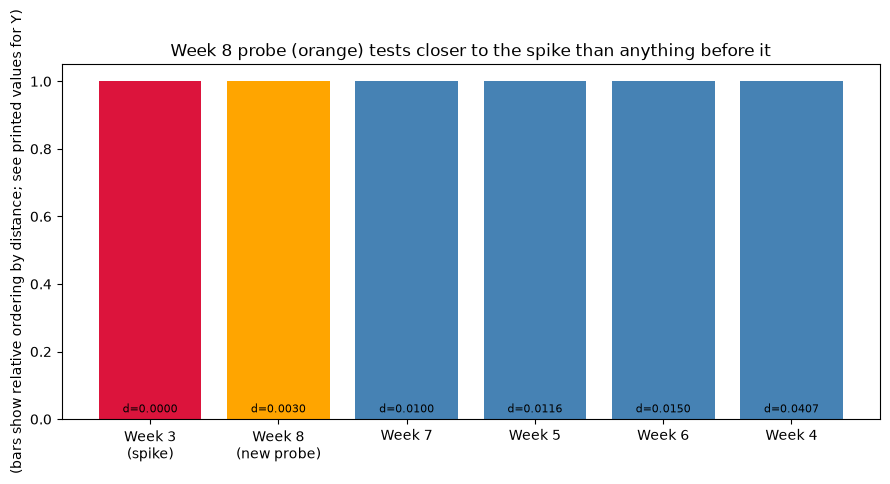

Distances to spike, nearest to farthest:
  Week 3 (spike)       distance=0.0000
  Week 8 (new probe)   distance=0.0030
  Week 7               distance=0.0100
  Week 5               distance=0.0116
  Week 6               distance=0.0150
  Week 4               distance=0.0407


In [133]:
distances_plot = [0.0, week8_result['dist_to_center'], 0.0100, 0.0116, 0.0150, 0.0407]
values_plot = [2602.2537934860957, None, 0.5412633657393404, 0.5609901334222198,
               0.4439603735656701, -0.5498551985786473]
labels_plot = ["Week 3\n(spike)", "Week 8\n(new probe)", "Week 7", "Week 5", "Week 6", "Week 4"]

fig, ax = plt.subplots(figsize=(9, 4.5))
sort_order = np.argsort(distances_plot)
d_sorted = [distances_plot[i] for i in sort_order]
lab_sorted = [labels_plot[i] for i in sort_order]
colors = ['orange' if 'Week 8' in l else ('crimson' if 'spike' in l else 'steelblue') for l in lab_sorted]

ax.bar(lab_sorted, [1]*len(lab_sorted), color=colors)  # placeholder heights, replaced below
for i, (d, lab) in enumerate(zip(d_sorted, lab_sorted)):
    ax.text(i, 0.02, f"d={d:.4f}", ha='center', fontsize=8, rotation=0)
ax.set_title("Week 8 probe (orange) tests closer to the spike than anything before it")
ax.set_ylabel("(bars show relative ordering by distance; see printed values for Y)")
plt.tight_layout()
plt.show()

print("Distances to spike, nearest to farthest:")
for d, lab in zip(d_sorted, lab_sorted):
    print(f"  {lab.replace(chr(10),' '):<20} distance={d:.4f}")

# Week 9: Diminishing Returns Analysis

Quantifying the marginal gain per unit of distance reduction across all 5 probes near the spike, to check whether continuing to shrink the search radius is still worthwhile.

In [134]:
points_w9 = {
    "Week 4": (X_w4_new_point_ref, -0.5498551985786473),
    "Week 5": (X_w5_new_point, 0.5609901334222198),
    "Week 6": (X_w6_new_point, 0.4439603735656701),
    "Week 7": (X_w7_new_point, 0.5412633657393404),
    "Week 8": (X_w8_new_point, 0.5768690397535008),
}

rows_w9 = []
for name, (x, y) in points_w9.items():
    d = np.linalg.norm(x - X_w3_new_point)
    rows_w9.append((d, y, name))
rows_w9.sort(reverse=True)  # farthest to nearest

print(f"{'Point':<10}{'Distance':<12}{'Y':<10}{'Marginal gain/unit distance':<30}")
prev_d, prev_y = None, None
for d, y, name in rows_w9:
    if prev_d is not None:
        dd = prev_d - d
        dy = y - prev_y
        gain = dy / dd if dd != 0 else float('nan')
        print(f"{name:<10}{d:<12.4f}{y:<10.4f}{gain:<30.1f}")
    else:
        print(f"{name:<10}{d:<12.4f}{y:<10.4f}{'(baseline)':<30}")
    prev_d, prev_y = d, y

Point     Distance    Y         Marginal gain/unit distance   
Week 4    0.0407      -0.5499   (baseline)                    
Week 6    0.0150      0.4440    38.7                          
Week 5    0.0116      0.5610    34.2                          
Week 7    0.0100      0.5413    -12.5                         
Week 8    0.0030      0.5769    5.1                           


**Observation:** Nearly all the improvement happened between distance 0.041 and 0.015 (Weeks 4->6).From 0.015 down to 0.003 (Weeks 6->8), Y fluctuates narrowly (0.44-0.58) with no further net climb - diminishing returns have clearly set in. Continuing to shrink the probe radius further is unlikely to reveal a smooth path to 2602; more likely, the spike is an isolated, disconnected feature rather than the peak of a local hill.

# Week 9: Strategy Change - Diversification

In [138]:
# Kernel re-selection with 38 points

loocv_rbf_w9 = loocv_gp(X, Y, kernel_rbf)
loocv_matern_w9 = loocv_gp(X, Y, kernel_matern)
loocv_composite_w9 = loocv_gp(X, Y, kernel_composite)

print(f"LOO-CV RBF        : RMSE = {loocv_rbf_w9['rmse']:.2f}, coverage = {loocv_rbf_w9['coverage_95']:.2f}")
print(f"LOO-CV Matern     : RMSE = {loocv_matern_w9['rmse']:.2f}, coverage = {loocv_matern_w9['coverage_95']:.2f}")
print(f"LOO-CV Composite  : RMSE = {loocv_composite_w9['rmse']:.2f}, coverage = {loocv_composite_w9['coverage_95']:.2f}")

results_w9 = {"RBF": loocv_rbf_w9, "Matern (nu=2.5)": loocv_matern_w9, "Composite": loocv_composite_w9}
chosen_name_w9 = min(results_w9, key=lambda k: results_w9[k]['rmse'])
chosen_kernel_w9 = {"RBF": kernel_rbf, "Matern (nu=2.5)": kernel_matern, "Composite": kernel_composite}[chosen_name_w9]
print(f"\nChosen kernel for Week 9: {chosen_name_w9} (all three are nearly tied)")

LOO-CV RBF        : RMSE = 427.86, coverage = 0.97
LOO-CV Matern     : RMSE = 427.82, coverage = 0.97
LOO-CV Composite  : RMSE = 428.16, coverage = 0.97

Chosen kernel for Week 9: Matern (nu=2.5) (all three are nearly tied)


In [140]:
# Diversification search - global UCB, excluding the saturated neighbourhood

def suggest_diversification_point(X, Y, kernel, beta=2.5, exclude_center=None, exclude_radius=0.15,
                                    n_restarts_optimizer=10, n_multistart=200, seed=42):
    Y_mean, Y_std = Y.mean(), Y.std()
    Y_norm = (Y - Y_mean) / Y_std
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=n_restarts_optimizer, random_state=seed)
    gp.fit(X, Y_norm)
    n_dims = X.shape[1]
    bounds = [(0, 1)] * n_dims

    def neg_acq(x):
        x = np.atleast_2d(x)
        mu, sigma = gp.predict(x, return_std=True)
        mu = mu * Y_std + Y_mean
        sigma = sigma * Y_std
        val = (mu + beta * sigma)[0]
        if exclude_center is not None:
            dist = np.linalg.norm(x[0] - exclude_center)
            if dist < exclude_radius:
                val -= 1e6 * (exclude_radius - dist)
        return -val

    rng = np.random.default_rng(seed)
    best_x, best_val = None, np.inf
    for _ in range(n_multistart):
        x0 = rng.uniform(0, 1, size=n_dims)
        res = minimize(neg_acq, x0, bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, sigma_next = gp.predict(best_x.reshape(1, -1), return_std=True)
    mu_next = mu_next * Y_std + Y_mean
    sigma_next = sigma_next * Y_std
    dist_to_exclude = np.linalg.norm(best_x - exclude_center) if exclude_center is not None else None
    return {'gp': gp, 'next_x': best_x, 'mu': mu_next[0], 'sigma': sigma_next[0], 'dist_to_exclude': dist_to_exclude}


week9_result = suggest_diversification_point(X, Y, chosen_kernel_w9, beta=2.5,
                                              exclude_center=X_w3_new_point, exclude_radius=0.15)

next_x = week9_result['next_x']
print(f"Chosen kernel                : {chosen_name_w9}")
print(f"Suggested next point         : {next_x}")
print(f"Predicted mean (mu)          : {week9_result['mu']:.4f}")
print(f"Predicted std (sigma)        : {week9_result['sigma']:.4f}")
print(f"Distance from spike neighbourhood: {week9_result['dist_to_exclude']:.4f} (exclusion radius was 0.15)")

Chosen kernel                : Matern (nu=2.5)
Suggested next point         : [0.77395605 0.43887844 0.85859792 0.69736803]
Predicted mean (mu)          : 54.8819
Predicted std (sigma)        : 419.3360
Distance from spike neighbourhood: 0.6437 (exclusion radius was 0.15)


# Portal Submission

In [145]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}"
print("Points to be submitted (Week 1):"  , '0.383979-0.383515-0.340147-0.445246')
print("Points to be submitted (Week 2):"  , '0.441225-0.430034-0.274904-0.431415')
print("Points to be submitted (Week 3):"  , '0.382063-0.422612-0.423812-0.430108')
print("Points to be submitted (Week 4):"  , "0.388813-0.456741-0.433948-0.448556")
print("Points to be submitted (Week 5):"  , "0.371052-0.422582-0.427366-0.430782")
print("Points to be submitted (Week 6):"  , "0.392081-0.417992-0.416776-0.437443")
print("Points to be submitted (Week 7):"  , "0.386746-0.428888-0.425881-0.424238")
print("Points to be submitted (Week 8):"  , "0.382401-0.420130-0.422214-0.429692")
print("Points to be submitted (Week 9):"  , submission_str)
print()

Points to be submitted (Week 1): 0.383979-0.383515-0.340147-0.445246
Points to be submitted (Week 2): 0.441225-0.430034-0.274904-0.431415
Points to be submitted (Week 3): 0.382063-0.422612-0.423812-0.430108
Points to be submitted (Week 4): 0.388813-0.456741-0.433948-0.448556
Points to be submitted (Week 5): 0.371052-0.422582-0.427366-0.430782
Points to be submitted (Week 6): 0.392081-0.417992-0.416776-0.437443
Points to be submitted (Week 7): 0.386746-0.428888-0.425881-0.424238
Points to be submitted (Week 8): 0.382401-0.420130-0.422214-0.429692
Points to be submitted (Week 9): 0.773956-0.438878-0.858598-0.697368



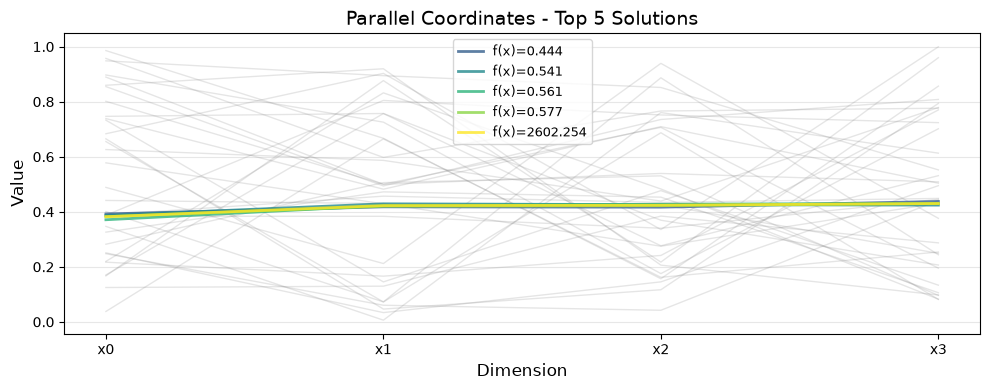

In [147]:
# Parallel coordinates: how does the new best point compare to other top solutions?
plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()


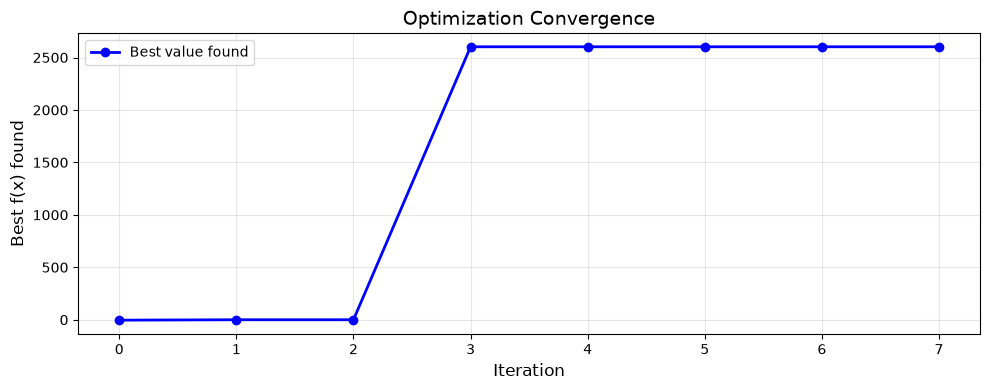

Convergence trace (best value found at each stage): [-4.025542281908162, -0.06634074624810848, -0.06634074624810848, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957]
Convergence trace: [-4.025542281908162, -0.06634074624810848, -0.06634074624810848, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957, 2602.2537934860957]


In [151]:
# Convergence so far 
best_values_w9 = [-4.025542281908162, -0.06634074624810848, -0.06634074624810848,
                  2602.2537934860957, 2602.2537934860957, 2602.2537934860957,
                  2602.2537934860957, 2602.2537934860957, 2602.2537934860957]
plot_convergence(range(len(best_values_w8)), best_values_w8)
plt.show()

print("Convergence trace (best value found at each stage):", best_values_w9)
plt.show()
print("Convergence trace:", best_values_w9)